# DSPy SST-2 Sentiment Classification Experiment

This notebook implements the experiment for comparing a manually designed baseline prompt with DSPy-based sentiment classification approaches.  
The experiment uses the SST-2 dataset from GLUE and a locally hosted `llama3.2:3b` model through Ollama.

Main evaluated approaches:

1. Manual baseline prompt  
2. DSPy unoptimized program  
3. DSPy optimized program using `BootstrapFewShot`  
4. DSPy optimized program using balanced optimization examples


In [3]:
import dspy
import datasets
import pandas as pd
import sklearn

print("dspy:", dspy.__version__)
print("datasets:", datasets.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

dspy: 3.2.1
datasets: 5.0.0
pandas: 3.0.3
sklearn: 1.9.0


## 1. Environment check

This cell prints the most important package versions. These values document the concrete implementation environment used for the experiment.


In [4]:
import os
import random
import pandas as pd

import dspy
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

## 2. Imports

This cell imports the libraries required for dataset loading, DSPy programming, evaluation metrics, and result storage.


In [5]:
dataset = load_dataset("nyu-mll/glue", "sst2")

dataset

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

c:\Users\ego\Desktop\University\5. Semester\Studienarbeit\Studeinarbeit\implementation\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ego\.cache\huggingface\hub\datasets--nyu-mll--glue. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

## 3. Result folder setup

The notebook stores outputs in two result folders: one for the 10-example pilot run and one for the 30-example final evaluation.


In [ ]:
from pathlib import Path

# Result folders used by the notebook.
# Pilot results are small smoke-test outputs.
# Final results are the main 30-example evaluation outputs.
PILOT_DIR = Path("results/pilot_10")
FINAL_DIR = Path("results/final_30")

PILOT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)


## 4. Dataset loading

This cell loads the SST-2 task from the GLUE benchmark using the Hugging Face Datasets library.


In [6]:
dataset["train"][0]

{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

## 5. Inspect one dataset example

This cell shows the structure of one SST-2 training example. Each example contains a sentence, a numerical label, and an index.


In [7]:
{'sentence': '...', 'label': 0, 'idx': ...}

{'sentence': '...', 'label': 0, 'idx': Ellipsis}

## 6. Label conversion

SST-2 uses numerical labels. This helper function converts them into textual labels that can be compared with LLM outputs.


In [8]:
def label_to_text(label: int) -> str:
    return "positive" if label == 1 else "negative"

print(dataset["train"][0]["sentence"])
print(dataset["train"][0]["label"])
print(label_to_text(dataset["train"][0]["label"]))

hide new secretions from the parental units 
0
negative


## 7. Select fixed subsets

The dataset is shuffled with a fixed random seed. A small training subset is used for optimization, and a validation subset is used for evaluation.


In [9]:
random.seed(42)

train_raw = dataset["train"].shuffle(seed=42).select(range(40))
dev_raw = dataset["validation"].shuffle(seed=42).select(range(80))

print(train_raw[0])
print(dev_raw[0])

{'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1, 'idx': 32326}
{'sentence': 'it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . ', 'label': 1, 'idx': 726}


## 8. Convert rows into DSPy examples

DSPy expects examples with clearly marked input fields. The sentence is marked as input, while the sentiment label remains the expected output.


In [10]:
def to_dspy_example(row):
    return dspy.Example(
        sentence=row["sentence"],
        sentiment=label_to_text(row["label"])
    ).with_inputs("sentence")

trainset = [to_dspy_example(row) for row in train_raw]
devset = [to_dspy_example(row) for row in dev_raw]

print(trainset[0])
print(devset[0])

Example({'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'sentiment': 'positive'}) (input_keys={'sentence'})
Example({'sentence': 'it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . ', 'sentiment': 'positive'}) (input_keys={'sentence'})


## 9. Configure the local language model with Ollama

This cell connects DSPy to the local Ollama runtime. Ollama must be running locally and the model `llama3.2:3b` must be installed before this cell is executed.


In [11]:
import dspy

lm = dspy.LM(
    "ollama_chat/llama3.2:3b",
    api_base="http://localhost:11434",
    temperature=0.0
)

dspy.configure(lm=lm)

## 10. Model smoke test

This quick test checks whether the local model connection works before the full experiment is executed.


In [12]:
response = lm("Classify the sentiment as positive or negative: This movie was wonderful.")
print(response)

['The sentiment of this statement is positive. The word "wonderful" has a strongly positive connotation, indicating that the speaker had a very good and enjoyable experience with the movie.']


## 11. Prediction normalization

The local model may return a full sentence instead of only `positive` or `negative`. The normalization function converts verbose outputs into comparable labels.


In [14]:
def extract_text(response):
    """
    DSPy/Ollama may return a list like ['positive'] or a plain string.
    This helper converts the response into a normal string.
    """
    if isinstance(response, list):
        return response[0] if len(response) > 0 else ""
    return str(response)


def normalize_prediction(response):
    """
    Converts model output into one of:
    positive, negative, unknown
    """
    text = extract_text(response).strip().lower()

    # Strong checks first
    if text == "positive":
        return "positive"
    if text == "negative":
        return "negative"

    # Common verbose-output cases
    if "positive" in text and "negative" not in text:
        return "positive"
    if "negative" in text and "positive" not in text:
        return "negative"

    # If both appear, inspect early output
    first_words = text[:80]
    if "positive" in first_words and "negative" not in first_words:
        return "positive"
    if "negative" in first_words and "positive" not in first_words:
        return "negative"

    return "unknown"

In [15]:
test_response = lm("Classify the sentiment as positive or negative: This movie was wonderful.")
print("Raw response:", test_response)
print("Normalized:", normalize_prediction(test_response))

Raw response: ['The sentiment of this statement is positive. The word "wonderful" has a strongly positive connotation, indicating that the speaker had a very good and enjoyable experience with the movie.']
Normalized: positive


## 12. Manual baseline prompt

This function implements the manually designed baseline prompt. It sends each SST-2 sentence to the local model and normalizes the response.


In [16]:
def manual_baseline_predict(sentence: str) -> str:
    prompt = f"""
You are a sentiment classification system.

Classify the sentiment of the following sentence.
Return exactly one word: positive or negative.
Do not explain your answer.

Sentence: "{sentence}"

Sentiment:
"""
    response = lm(prompt)
    return normalize_prediction(response)

In [17]:
example = devset[0]

print("Sentence:", example.sentence)
print("Gold:", example.sentiment)
print("Prediction:", manual_baseline_predict(example.sentence))

Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Prediction: positive


## 13. Pilot evaluation with 10 validation examples

The 10-example pilot run verifies that the baseline, normalization, and metric calculation work correctly before running the larger evaluation.


In [18]:
devset_small = devset[:10]

baseline_predictions = []
gold_labels = []

for i, ex in enumerate(devset_small, start=1):
    pred = manual_baseline_predict(ex.sentence)
    baseline_predictions.append(pred)
    gold_labels.append(ex.sentiment)

    print(f"{i}/10")
    print("Sentence:", ex.sentence)
    print("Gold:", ex.sentiment)
    print("Pred:", pred)
    print("-" * 50)

baseline_acc = accuracy_score(gold_labels, baseline_predictions)

print("Manual baseline accuracy:", baseline_acc)
print(classification_report(gold_labels, baseline_predictions, labels=["negative", "positive", "unknown"], zero_division=0))

1/10
Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Pred: positive
--------------------------------------------------
2/10
Sentence: my big fat greek wedding uses stereotypes in a delightful blend of sweet romance and lovingly dished out humor . 
Gold: positive
Pred: positive
--------------------------------------------------
3/10
Sentence: for the most part , director anne-sophie birot 's first feature is a sensitive , extraordinarily well-acted drama . 
Gold: positive
Pred: positive
--------------------------------------------------
4/10
Sentence: cq 's reflection of artists and the love of cinema-and-self suggests nothing less than a new voice that deserves to be considered as a possible successor to the best european directors . 
Gold: positive
Pred: positive
--------------------------------------------------
5/10
Sentence: charles ' entertaining film chronicles sei

In [19]:
import pandas as pd

baseline_df = pd.DataFrame({
    "sentence": [ex.sentence for ex in devset_small],
    "gold": gold_labels,
    "manual_baseline_prediction": baseline_predictions
})

baseline_df["manual_correct"] = baseline_df["gold"] == baseline_df["manual_baseline_prediction"]

baseline_df

,sentence,gold,manual_baseline_prediction,manual_correct
0,it gets onto the screen just about as much of ...,positive,positive,True
1,my big fat greek wedding uses stereotypes in a...,positive,positive,True
2,"for the most part , director anne-sophie birot...",positive,positive,True
3,cq 's reflection of artists and the love of ci...,positive,positive,True
4,charles ' entertaining film chronicles seinfel...,positive,negative,False
5,and that leaves a hole in the center of the sa...,negative,negative,True
6,the film tunes into a grief that could lead a ...,positive,negative,False
7,or doing last year 's taxes with your ex-wife .,negative,negative,True
8,"the weight of the piece , the unerring profess...",positive,positive,True
9,too much of it feels unfocused and underdevelo...,negative,negative,True


In [20]:
baseline_df.to_csv(PILOT_DIR / "manual_baseline_results_10.csv", index=False)

## 14. DSPy signature and module

This cell defines the DSPy program. The signature describes the input-output behavior, and the module wraps the prediction call into a reusable component.


In [21]:
class SentimentSignature(dspy.Signature):
    """Classify the sentiment of a sentence as positive or negative."""

    sentence: str = dspy.InputField(desc="A movie review sentence.")
    sentiment: str = dspy.OutputField(desc="Return exactly one word: positive or negative.")


class SentimentClassifier(dspy.Module):
    def __init__(self):
        super().__init__()
        self.classify = dspy.Predict(SentimentSignature)

    def forward(self, sentence):
        prediction = self.classify(sentence=sentence)
        prediction.sentiment = normalize_prediction(prediction.sentiment)
        return prediction

In [22]:
dspy_program = SentimentClassifier()

test_prediction = dspy_program(sentence="This movie was wonderful.")
print(test_prediction)
print("Normalized sentiment:", test_prediction.sentiment)

Prediction(
    sentiment='positive'
)
Normalized sentiment: positive


## 15. Shared evaluation function

This helper evaluates any DSPy program on a list of examples and returns both accuracy and a detailed result table.


In [23]:
def evaluate_program(program, examples, approach_name="DSPy program"):
    predictions = []
    gold = []
    rows = []

    for i, ex in enumerate(examples, start=1):
        pred_obj = program(sentence=ex.sentence)
        pred = normalize_prediction(pred_obj.sentiment)

        predictions.append(pred)
        gold.append(ex.sentiment)

        rows.append({
            "index": i,
            "sentence": ex.sentence,
            "gold": ex.sentiment,
            "prediction": pred,
            "correct": ex.sentiment == pred,
            "approach": approach_name
        })

        print(f"{i}/{len(examples)}")
        print("Sentence:", ex.sentence)
        print("Gold:", ex.sentiment)
        print("Pred:", pred)
        print("-" * 50)

    acc = accuracy_score(gold, predictions)
    report = classification_report(
        gold,
        predictions,
        labels=["negative", "positive", "unknown"],
        zero_division=0
    )

    print(f"{approach_name} accuracy:", acc)
    print(report)

    return acc, pd.DataFrame(rows)

## 16. Pilot evaluation of the unoptimized DSPy program

This cell evaluates the DSPy program before applying a DSPy optimizer.


In [24]:
unoptimized_acc, unoptimized_df = evaluate_program(
    dspy_program,
    devset_small,
    approach_name="DSPy unoptimized program"
)

unoptimized_df.to_csv(PILOT_DIR / "dspy_unoptimized_results_10.csv", index=False)

1/10
Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Pred: positive
--------------------------------------------------
2/10
Sentence: my big fat greek wedding uses stereotypes in a delightful blend of sweet romance and lovingly dished out humor . 
Gold: positive
Pred: positive
--------------------------------------------------
3/10
Sentence: for the most part , director anne-sophie birot 's first feature is a sensitive , extraordinarily well-acted drama . 
Gold: positive
Pred: positive
--------------------------------------------------
4/10
Sentence: cq 's reflection of artists and the love of cinema-and-self suggests nothing less than a new voice that deserves to be considered as a possible successor to the best european directors . 
Gold: positive
Pred: positive
--------------------------------------------------
5/10
Sentence: charles ' entertaining film chronicles sei

In [28]:
comparison_10 = pd.DataFrame({
    "sentence": [ex.sentence for ex in devset_small],
    "gold": gold_labels,
    "manual_prediction": baseline_predictions,
    "manual_correct": [g == p for g, p in zip(gold_labels, baseline_predictions)],
    "dspy_unoptimized_prediction": unoptimized_df["prediction"].tolist(),
    "dspy_unoptimized_correct": unoptimized_df["correct"].tolist()
})

comparison_10.to_csv(PILOT_DIR / "comparison_manual_vs_dspy_unoptimized_10.csv", index=False)

comparison_10

,sentence,gold,manual_prediction,manual_correct,dspy_unoptimized_prediction,dspy_unoptimized_correct
0,it gets onto the screen just about as much of ...,positive,positive,True,positive,True
1,my big fat greek wedding uses stereotypes in a...,positive,positive,True,positive,True
2,"for the most part , director anne-sophie birot...",positive,positive,True,positive,True
3,cq 's reflection of artists and the love of ci...,positive,positive,True,positive,True
4,charles ' entertaining film chronicles seinfel...,positive,negative,False,positive,True
5,and that leaves a hole in the center of the sa...,negative,negative,True,negative,True
6,the film tunes into a grief that could lead a ...,positive,negative,False,negative,False
7,or doing last year 's taxes with your ex-wife .,negative,negative,True,negative,True
8,"the weight of the piece , the unerring profess...",positive,positive,True,positive,True
9,too much of it feels unfocused and underdevelo...,negative,negative,True,negative,True


## 17. Pilot DSPy optimization

This cell applies `BootstrapFewShot` on a very small training subset to check whether DSPy optimization runs successfully.


In [29]:
trainset_small = trainset[:8]

try:
    from dspy.teleprompt import BootstrapFewShot
except ImportError:
    BootstrapFewShot = dspy.BootstrapFewShot


def sentiment_metric(example, prediction, trace=None):
    gold = normalize_prediction(example.sentiment)
    pred = normalize_prediction(prediction.sentiment)
    return 1.0 if gold == pred else 0.0


optimizer = BootstrapFewShot(
    metric=sentiment_metric,
    max_bootstrapped_demos=2,
    max_labeled_demos=4,
    max_rounds=1
)

compiled_program = optimizer.compile(
    student=SentimentClassifier(),
    trainset=trainset_small
)

 88%|████████▊ | 7/8 [00:39<00:05,  5.67s/it]

Bootstrapped 2 full traces after 7 examples for up to 1 rounds, amounting to 7 attempts.


In [30]:
optimized_acc, optimized_df = evaluate_program(
    compiled_program,
    devset_small,
    approach_name="DSPy optimized program"
)

optimized_df.to_csv(PILOT_DIR / "dspy_optimized_results_10.csv", index=False)

1/10
Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Pred: positive
--------------------------------------------------
2/10
Sentence: my big fat greek wedding uses stereotypes in a delightful blend of sweet romance and lovingly dished out humor . 
Gold: positive
Pred: positive
--------------------------------------------------
3/10
Sentence: for the most part , director anne-sophie birot 's first feature is a sensitive , extraordinarily well-acted drama . 
Gold: positive
Pred: positive
--------------------------------------------------
4/10
Sentence: cq 's reflection of artists and the love of cinema-and-self suggests nothing less than a new voice that deserves to be considered as a possible successor to the best european directors . 
Gold: positive
Pred: positive
--------------------------------------------------
5/10
Sentence: charles ' entertaining film chronicles sei

## 18. Pilot result summary

This table summarizes the 10-example pilot run. The pilot results are used only as a smoke test, not as the main evaluation.


In [31]:
summary_results = pd.DataFrame([
    {
        "approach": "Manual baseline prompt",
        "accuracy": baseline_acc,
        "num_examples": len(devset_small)
    },
    {
        "approach": "DSPy unoptimized program",
        "accuracy": unoptimized_acc,
        "num_examples": len(devset_small)
    },
    {
        "approach": "DSPy optimized program",
        "accuracy": optimized_acc,
        "num_examples": len(devset_small)
    }
])

summary_results.to_csv(PILOT_DIR / "summary_results_10.csv", index=False)
summary_results

,approach,accuracy,num_examples
0,Manual baseline prompt,0.8,10
1,DSPy unoptimized program,0.9,10
2,DSPy optimized program,0.8,10


In [35]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.2 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 22.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 21.0 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 37.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 57.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   -----

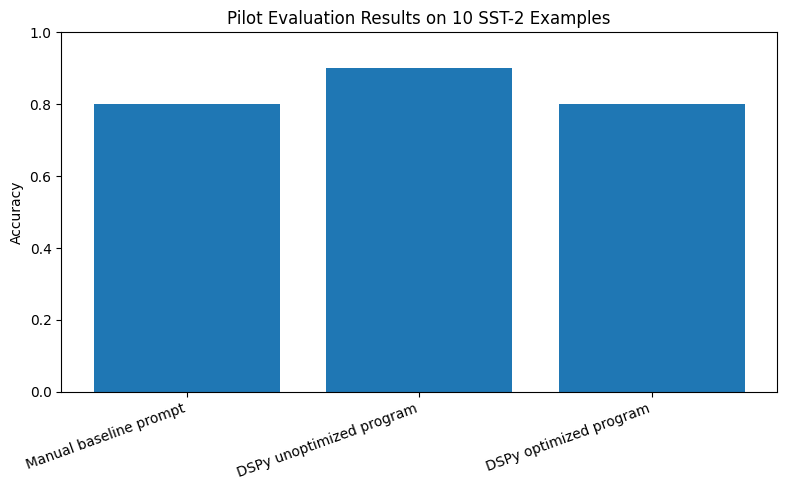

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(summary_results["approach"], summary_results["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Pilot Evaluation Results on 10 SST-2 Examples")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PILOT_DIR / "pilot_accuracy_results_10.png", dpi=300)
plt.show()

# Final 30-example evaluation

The following cells run the main evaluation used in the thesis. The evaluation uses 30 fixed examples from the SST-2 validation split.


In [37]:
devset_30 = devset[:30]
trainset_20 = trainset[:20]

## 19. Manual baseline on 30 validation examples

This cell evaluates the manually designed prompt on the final 30-example validation subset.


In [38]:
baseline_predictions_30 = []
gold_labels_30 = []

for i, ex in enumerate(devset_30, start=1):
    pred = manual_baseline_predict(ex.sentence)
    baseline_predictions_30.append(pred)
    gold_labels_30.append(ex.sentiment)

    print(f"{i}/30 | Gold: {ex.sentiment} | Pred: {pred}")

baseline_acc_30 = accuracy_score(gold_labels_30, baseline_predictions_30)

print("Manual baseline accuracy on 30 examples:", baseline_acc_30)
print(classification_report(gold_labels_30, baseline_predictions_30, labels=["negative", "positive", "unknown"], zero_division=0))

1/30 | Gold: positive | Pred: positive
2/30 | Gold: positive | Pred: positive
3/30 | Gold: positive | Pred: positive
4/30 | Gold: positive | Pred: positive
5/30 | Gold: positive | Pred: negative
6/30 | Gold: negative | Pred: negative
7/30 | Gold: positive | Pred: negative
8/30 | Gold: negative | Pred: negative
9/30 | Gold: positive | Pred: positive
10/30 | Gold: negative | Pred: negative
11/30 | Gold: negative | Pred: negative
12/30 | Gold: positive | Pred: negative
13/30 | Gold: positive | Pred: positive
14/30 | Gold: positive | Pred: negative
15/30 | Gold: positive | Pred: positive
16/30 | Gold: negative | Pred: negative
17/30 | Gold: positive | Pred: positive
18/30 | Gold: negative | Pred: negative
19/30 | Gold: positive | Pred: negative
20/30 | Gold: negative | Pred: negative
21/30 | Gold: negative | Pred: negative
22/30 | Gold: positive | Pred: positive
23/30 | Gold: negative | Pred: negative
24/30 | Gold: negative | Pred: negative
25/30 | Gold: negative | Pred: negative
26/30 | G

## 20. Unoptimized DSPy program on 30 validation examples

This cell evaluates the structured DSPy program without optimization on the same 30 validation examples.


In [39]:
unoptimized_acc_30, unoptimized_df_30 = evaluate_program(
    dspy_program,
    devset_30,
    approach_name="DSPy unoptimized program"
)

unoptimized_df_30.to_csv(FINAL_DIR / "dspy_unoptimized_results_30.csv", index=False)

1/30
Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Pred: positive
--------------------------------------------------
2/30
Sentence: my big fat greek wedding uses stereotypes in a delightful blend of sweet romance and lovingly dished out humor . 
Gold: positive
Pred: positive
--------------------------------------------------
3/30
Sentence: for the most part , director anne-sophie birot 's first feature is a sensitive , extraordinarily well-acted drama . 
Gold: positive
Pred: positive
--------------------------------------------------
4/30
Sentence: cq 's reflection of artists and the love of cinema-and-self suggests nothing less than a new voice that deserves to be considered as a possible successor to the best european directors . 
Gold: positive
Pred: positive
--------------------------------------------------
5/30
Sentence: charles ' entertaining film chronicles sei

## 21. DSPy optimization with the first 20 training examples

This cell applies `BootstrapFewShot` using 20 selected training examples.


In [40]:
optimizer_20 = BootstrapFewShot(
    metric=sentiment_metric,
    max_bootstrapped_demos=4,
    max_labeled_demos=8,
    max_rounds=1
)

compiled_program_20 = optimizer_20.compile(
    student=SentimentClassifier(),
    trainset=trainset_20
)

 25%|██▌       | 5/20 [00:27<01:23,  5.58s/it]

Bootstrapped 4 full traces after 5 examples for up to 1 rounds, amounting to 5 attempts.


## 22. Optimized DSPy program on 30 validation examples

This cell evaluates the optimized DSPy program on the same validation subset.


In [41]:
optimized_acc_30, optimized_df_30 = evaluate_program(
    compiled_program_20,
    devset_30,
    approach_name="DSPy optimized program"
)

optimized_df_30.to_csv(FINAL_DIR / "dspy_optimized_results_30.csv", index=False)

1/30
Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Pred: positive
--------------------------------------------------
2/30
Sentence: my big fat greek wedding uses stereotypes in a delightful blend of sweet romance and lovingly dished out humor . 
Gold: positive
Pred: positive
--------------------------------------------------
3/30
Sentence: for the most part , director anne-sophie birot 's first feature is a sensitive , extraordinarily well-acted drama . 
Gold: positive
Pred: positive
--------------------------------------------------
4/30
Sentence: cq 's reflection of artists and the love of cinema-and-self suggests nothing less than a new voice that deserves to be considered as a possible successor to the best european directors . 
Gold: positive
Pred: positive
--------------------------------------------------
5/30
Sentence: charles ' entertaining film chronicles sei

In [42]:
summary_results_30 = pd.DataFrame([
    {
        "approach": "Manual baseline prompt",
        "accuracy": baseline_acc_30,
        "num_examples": len(devset_30)
    },
    {
        "approach": "DSPy unoptimized program",
        "accuracy": unoptimized_acc_30,
        "num_examples": len(devset_30)
    },
    {
        "approach": "DSPy optimized program",
        "accuracy": optimized_acc_30,
        "num_examples": len(devset_30)
    }
])

summary_results_30.to_csv(FINAL_DIR / "summary_results_30.csv", index=False)
summary_results_30

,approach,accuracy,num_examples
0,Manual baseline prompt,0.766667,30
1,DSPy unoptimized program,0.833333,30
2,DSPy optimized program,0.666667,30


## 23. Class distribution check

This cell checks whether the optimization and evaluation subsets are balanced with respect to positive and negative labels.


In [43]:
from collections import Counter

print("trainset_20 labels:", Counter([ex.sentiment for ex in trainset_20]))
print("devset_30 labels:", Counter([ex.sentiment for ex in devset_30]))

trainset_20 labels: Counter({'positive': 14, 'negative': 6})
devset_30 labels: Counter({'positive': 16, 'negative': 14})


## 24. Balanced optimization examples

This cell constructs a balanced optimization set with 10 positive and 10 negative examples.


In [44]:
positive_train = [ex for ex in trainset if ex.sentiment == "positive"]
negative_train = [ex for ex in trainset if ex.sentiment == "negative"]

balanced_trainset_20 = positive_train[:10] + negative_train[:10]

random.seed(42)
random.shuffle(balanced_trainset_20)

print("balanced_trainset_20 labels:", Counter([ex.sentiment for ex in balanced_trainset_20]))

balanced_trainset_20 labels: Counter({'negative': 10, 'positive': 10})


## 25. DSPy optimization with balanced examples

This cell applies `BootstrapFewShot` again, this time using the balanced optimization set.


In [45]:
optimizer_balanced = BootstrapFewShot(
    metric=sentiment_metric,
    max_bootstrapped_demos=4,
    max_labeled_demos=8,
    max_rounds=1
)

compiled_program_balanced = optimizer_balanced.compile(
    student=SentimentClassifier(),
    trainset=balanced_trainset_20
)

 25%|██▌       | 5/20 [00:44<02:14,  8.96s/it]

Bootstrapped 4 full traces after 5 examples for up to 1 rounds, amounting to 5 attempts.


## 26. Balanced optimized DSPy program evaluation

This cell evaluates the balanced optimized DSPy program on the same 30 validation examples.


In [46]:
optimized_balanced_acc_30, optimized_balanced_df_30 = evaluate_program(
    compiled_program_balanced,
    devset_30,
    approach_name="DSPy optimized balanced program"
)

optimized_balanced_df_30.to_csv(FINAL_DIR / "dspy_optimized_balanced_results_30.csv", index=False)

1/30
Sentence: it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right . 
Gold: positive
Pred: positive
--------------------------------------------------
2/30
Sentence: my big fat greek wedding uses stereotypes in a delightful blend of sweet romance and lovingly dished out humor . 
Gold: positive
Pred: positive
--------------------------------------------------
3/30
Sentence: for the most part , director anne-sophie birot 's first feature is a sensitive , extraordinarily well-acted drama . 
Gold: positive
Pred: positive
--------------------------------------------------
4/30
Sentence: cq 's reflection of artists and the love of cinema-and-self suggests nothing less than a new voice that deserves to be considered as a possible successor to the best european directors . 
Gold: positive
Pred: positive
--------------------------------------------------
5/30
Sentence: charles ' entertaining film chronicles sei

## 27. Final accuracy summary

This table contains the main accuracy comparison used in the thesis.


In [47]:
summary_results_30_extended = pd.DataFrame([
    {
        "approach": "Manual baseline prompt",
        "accuracy": baseline_acc_30,
        "num_examples": len(devset_30)
    },
    {
        "approach": "DSPy unoptimized program",
        "accuracy": unoptimized_acc_30,
        "num_examples": len(devset_30)
    },
    {
        "approach": "DSPy optimized program",
        "accuracy": optimized_acc_30,
        "num_examples": len(devset_30)
    },
    {
        "approach": "DSPy optimized balanced program",
        "accuracy": optimized_balanced_acc_30,
        "num_examples": len(devset_30)
    }
])

summary_results_30_extended.to_csv(FINAL_DIR / "summary_results_30_extended.csv", index=False)
summary_results_30_extended

,approach,accuracy,num_examples
0,Manual baseline prompt,0.766667,30
1,DSPy unoptimized program,0.833333,30
2,DSPy optimized program,0.666667,30
3,DSPy optimized balanced program,0.733333,30


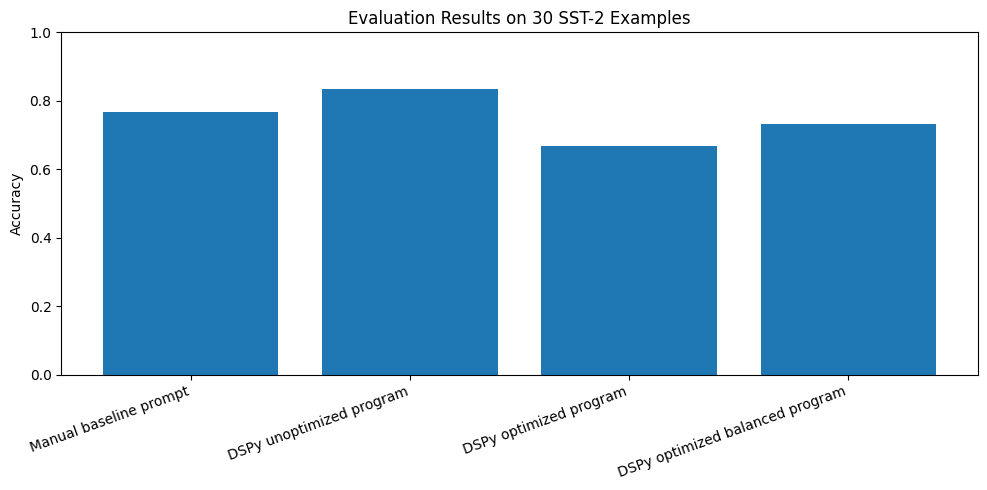

In [48]:
plt.figure(figsize=(10, 5))
plt.bar(summary_results_30_extended["approach"], summary_results_30_extended["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Evaluation Results on 30 SST-2 Examples")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FINAL_DIR / "accuracy_results_30_extended.png", dpi=300)
plt.show()